# 02 - Exploratory Data Analysis

This notebook documents the exploratory data analysis (EDA) step for the financial fraud detection pipeline.

In the MLOps-DSPM, this corresponds to the **Data Collection, Exploration, and Preparation** phase, especially the **DP06 data exploration** activity. The goal is to understand the preprocessed dataset before modeling, not to train a model or make final feature-selection decisions.



## Cell 1 - Import libraries

This cell loads the Python packages used for the notebook. `pandas` is used for tabular analysis, `Path` keeps file paths readable, and `display` renders data frames below each cell in the notebook.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Libraries imported successfully.")


Libraries imported successfully.


## Cell 2 - Define paths and analysis columns

This cell defines where the preprocessed gold table is stored and which columns are treated as categorical, numeric, timestamp, and target fields. Keeping these lists explicit makes the EDA reproducible and easier to audit.


In [2]:
BASE_DIR = Path(r"D:\Germany\Documents\Magdeburg\Semester Documents\Sem 5\Thesis\Code snippets")
INPUT_FILE = BASE_DIR / "gold_financial_fraud_detection_table.csv"

TARGET_COLUMN = "is_fraud"
TIMESTAMP_COLUMN = "event_timestamp"

CATEGORICAL_COLUMNS = ['transaction_type', 'merchant_category', 'location', 'device_used', 'payment_channel']
NUMERIC_COLUMNS = ['amount', 'amount_log1p', 'time_since_last_transaction', 'time_since_last_transaction_missing_flag', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'transaction_hour', 'transaction_day_of_week', 'transaction_month']
REQUIRED_COLUMNS = ['amount', 'amount_log1p', 'device_used', 'event_timestamp', 'geo_anomaly_score', 'is_fraud', 'location', 'merchant_category', 'payment_channel', 'spending_deviation_score', 'time_since_last_transaction', 'time_since_last_transaction_missing_flag', 'transaction_day_of_week', 'transaction_hour', 'transaction_id', 'transaction_month', 'transaction_type', 'velocity_score']

DTYPE_MAP = {'transaction_id': 'string', 'transaction_type': 'category', 'merchant_category': 'category', 'location': 'category', 'device_used': 'category', 'payment_channel': 'category', 'amount': 'float64', 'amount_log1p': 'float64', 'time_since_last_transaction': 'float64', 'time_since_last_transaction_missing_flag': 'int8', 'spending_deviation_score': 'float64', 'velocity_score': 'int16', 'geo_anomaly_score': 'float64', 'transaction_hour': 'int8', 'transaction_day_of_week': 'int8', 'transaction_month': 'int8', 'is_fraud': 'int8'}

print("Input file:", INPUT_FILE)
print("Input file exists:", INPUT_FILE.exists())


Input file: D:\Germany\Documents\Magdeburg\Semester Documents\Sem 5\Thesis\Code snippets\gold_financial_fraud_detection_table.csv
Input file exists: True


## Cell 3 - Load the preprocessed gold table

This cell reads the output of the preprocessing step. The raw dataset is not loaded here because this notebook is meant to explore the cleaned, leakage-aware table that will be handed to the modeling pipeline.


In [3]:
df = pd.read_csv(INPUT_FILE, dtype=DTYPE_MAP, parse_dates=[TIMESTAMP_COLUMN])

print("Loaded table shape:", df.shape)
print("Date range:", df[TIMESTAMP_COLUMN].min(), "to", df[TIMESTAMP_COLUMN].max())
display(df.head())


Loaded table shape: (4277262, 18)
Date range: 2023-01-01 00:11:36.452582 to 2024-01-01 22:58:30.131850


transaction_id,event_timestamp,transaction_type,merchant_category,location,device_used,payment_channel,amount,amount_log1p,time_since_last_transaction,time_since_last_transaction_missing_flag,spending_deviation_score,velocity_score,geo_anomaly_score,transaction_hour,transaction_day_of_week,transaction_month,is_fraud
T100000,2023-08-22 09:22:43.516168,withdrawal,utilities,Tokyo,mobile,card,343.78,5.842907,-1.0,1,-0.21,3,0.22,9,1,8,0
T100001,2023-08-04 01:58:02.606711,withdrawal,online,Toronto,atm,ACH,419.65,6.041801,-1.0,1,-0.14,7,0.96,1,4,8,0
T100002,2023-05-12 11:39:33.742963,deposit,other,London,pos,card,2773.86,7.928356,-1.0,1,-1.78,20,0.89,11,4,5,0
T100003,2023-10-10 06:04:43.195112,deposit,online,Sydney,pos,wire_transfer,1666.22,7.418913,-1.0,1,-0.60,6,0.37,6,1,10,0
T100004,2023-09-24 08:09:02.700162,transfer,utilities,Toronto,mobile,ACH,24.43,3.235930,-1.0,1,0.79,13,0.27,8,6,9,0


## Cell 4 - Validate the expected schema

This cell checks whether the preprocessed table still has the expected columns. It also summarizes data types, missing values, and unique values. This is useful because schema drift would make later model results difficult to interpret.


In [4]:
missing_columns = set(REQUIRED_COLUMNS) - set(df.columns)
extra_columns = set(df.columns) - set(REQUIRED_COLUMNS)

schema = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().sum().values / len(df)) * 100,
    "unique_count": df.nunique(dropna=True).values,
})
schema["missing_percentage"] = schema["missing_percentage"].round(6)

print("Missing required columns:", missing_columns)
print("Extra columns:", extra_columns)
display(schema)


Missing required columns: set()
Extra columns: set()


column,dtype,missing_count,missing_percentage,unique_count
transaction_id,string,0,0.0,4277262
event_timestamp,datetime64[us],0,0.0,4277260
transaction_type,category,0,0.0,4
merchant_category,category,0,0.0,8
location,category,0,0.0,8
device_used,category,0,0.0,4
payment_channel,category,0,0.0,4
amount,float64,0,0.0,213571
amount_log1p,float64,0,0.0,213571
time_since_last_transaction,float64,0,0.0,3384978


## Cell 5 - Create a high-level dataset overview

This cell gives a compact overview of the dataset: number of rows, time range, fraud count, fraud rate, duplicates, missing values, and memory usage. This is the first sanity check before deeper analysis.


In [5]:
row_count = len(df)
fraud_count = int(df[TARGET_COLUMN].sum())
non_fraud_count = int(row_count - fraud_count)
fraud_rate = fraud_count / row_count

overview = pd.DataFrame([
    ("rows", f"{row_count:,}"),
    ("columns", df.shape[1]),
    ("date_min", df[TIMESTAMP_COLUMN].min()),
    ("date_max", df[TIMESTAMP_COLUMN].max()),
    ("fraud_count", f"{fraud_count:,}"),
    ("non_fraud_count", f"{non_fraud_count:,}"),
    ("fraud_rate", round(fraud_rate, 6)),
    ("fraud_rate_percent", round(fraud_rate * 100, 4)),
    ("duplicate_transaction_ids", int(df["transaction_id"].duplicated().sum())),
    ("missing_values_total", int(df.isna().sum().sum())),
    ("memory_mb", round(df.memory_usage(deep=True).sum() / (1024 * 1024), 4)),
], columns=["metric", "value"])

display(overview)


metric,value
rows,"4,277,262"
columns,18
date_min,2023-01-01 00:11:36.452582
date_max,2024-01-01 22:58:30.131850
fraud_count,"147,881"
non_fraud_count,"4,129,381"
fraud_rate,0.034574
fraud_rate_percent,3.4574
duplicate_transaction_ids,0
missing_values_total,0


## Cell 6 - Inspect the target distribution

This cell checks how many transactions are fraudulent and non-fraudulent. Fraud detection usually has class imbalance, so this step justifies later model-evaluation choices such as precision, recall, F1-score, PR-AUC, and threshold analysis instead of accuracy alone.


In [6]:
target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="row_count")
    .sort_values(TARGET_COLUMN)
)
target_distribution["percentage"] = (target_distribution["row_count"] / len(df) * 100).round(4)
target_distribution["label"] = target_distribution[TARGET_COLUMN].map({0: "non_fraud", 1: "fraud"})
target_distribution = target_distribution[["label", TARGET_COLUMN, "row_count", "percentage"]]

display(target_distribution)


label,is_fraud,row_count,percentage
non_fraud,0,"4,129,381",96.5426
fraud,1,"147,881",3.4574


## Cell 7 - Summarize numeric features

This cell describes the numeric variables using percentiles and summary statistics. The aim is to understand ranges, skewness, unusual values, and whether later transformations may be needed in the modeling pipeline.


In [7]:
numeric_summary = df[NUMERIC_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T.reset_index(names="feature").round(4)

display(numeric_summary)


feature,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
amount,4277262.0,359.0144,470.0519,0.0100,0.0100,6.1500,26.5700,138.6500,503.9600,1420.3800,1876.0239,3520.5700
amount_log1p,4277262.0,4.7446,1.7914,0.0100,0.0100,1.9671,3.3167,4.9391,6.2245,7.2594,7.5374,8.1667
time_since_last_transaction,4277262.0,1.3003,3181.8662,-8777.8142,-7368.5951,-5645.1153,-1792.3105,-1.0000,1798.6509,5646.5471,7370.9745,8757.7585
time_since_last_transaction_missing_flag,4277262.0,0.2086,0.4063,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
spending_deviation_score,4277262.0,-0.0003,1.0006,-5.2600,-2.3300,-1.6500,-0.6800,-0.0000,0.6700,1.6500,2.3300,5.0200
velocity_score,4277262.0,10.5022,5.7673,1.0000,1.0000,1.0000,5.0000,11.0000,16.0000,20.0000,20.0000,20.0000
geo_anomaly_score,4277262.0,0.5000,0.2886,0.0000,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900,1.0000
transaction_hour,4277262.0,11.4972,6.9213,0.0000,0.0000,1.0000,5.0000,11.0000,17.0000,22.0000,23.0000,23.0000
transaction_day_of_week,4277262.0,2.9996,2.0033,0.0000,0.0000,0.0000,1.0000,3.0000,5.0000,6.0000,6.0000,6.0000
transaction_month,4277262.0,6.5272,3.4479,1.0000,1.0000,1.0000,4.0000,7.0000,10.0000,12.0000,12.0000,12.0000


## Cell 8 - Compare numeric features by target class

This cell compares numeric feature distributions for fraudulent and non-fraudulent transactions. It helps identify descriptive differences, but it is not feature selection because no model is trained and no preprocessing parameter is learned.


In [8]:
numeric_by_target_parts = []

for column in NUMERIC_COLUMNS:
    grouped = (
        df.groupby(TARGET_COLUMN, observed=True)[column]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )
    grouped.insert(0, "feature", column)
    numeric_by_target_parts.append(grouped)

numeric_by_target = pd.concat(numeric_by_target_parts, ignore_index=True).round(4)
display(numeric_by_target)


feature,is_fraud,count,mean,median,std,min,max
amount,0,4129381,359.0227,138.6600,470.0676,0.0100,3520.5700
amount,1,147881,358.7822,138.4400,469.6152,0.0100,3128.1400
amount_log1p,0,4129381,4.7446,4.9392,1.7915,0.0100,8.1667
amount_log1p,1,147881,4.7458,4.9376,1.7877,0.0100,8.0485
time_since_last_transaction,0,4129381,1.0644,-1.0000,3166.8235,-8777.8142,8757.7585
time_since_last_transaction,1,147881,7.8874,5.4508,3576.4598,-8748.1664,8744.7747
time_since_last_transaction_missing_flag,0,4129381,0.2161,0.0000,0.4116,0.0000,1.0000
time_since_last_transaction_missing_flag,1,147881,0.0000,0.0000,0.0000,0.0000,0.0000
spending_deviation_score,0,4129381,-0.0003,0.0000,1.0005,-5.2600,5.0200
spending_deviation_score,1,147881,-0.0003,-0.0000,1.0013,-4.4000,4.9000


## Cell 9 - Analyze categorical features

This cell calculates transaction counts, fraud counts, average amounts, and fraud rates for each categorical feature. This helps reveal whether some groups have slightly higher fraud rates, while still avoiding model training or target-based preprocessing.


In [9]:
def categorical_summary(column: str) -> pd.DataFrame:
    summary = (
        df.groupby(column, observed=True)
        .agg(
            row_count=(TARGET_COLUMN, "size"),
            fraud_count=(TARGET_COLUMN, "sum"),
            amount_mean=("amount", "mean"),
            amount_median=("amount", "median"),
        )
        .reset_index()
    )
    summary["row_percentage"] = summary["row_count"] / len(df) * 100
    summary["fraud_rate"] = summary["fraud_count"] / summary["row_count"]
    summary = summary.loc[summary["row_count"] >= 1_000]
    return summary.sort_values(["fraud_rate", "row_count"], ascending=[False, False]).round(6)

categorical_summaries = {}

for column in CATEGORICAL_COLUMNS:
    categorical_summaries[column] = categorical_summary(column)
    print(column)
    display(categorical_summaries[column].head(15))


transaction_type


transaction_type,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
transfer,1069550,37343,25.651963,20.08,25.005482,0.034915
withdrawal,1068386,36952,305.888700,300.14,24.978269,0.034587
deposit,1070056,36951,1004.151481,1000.54,25.017312,0.034532
payment,1069270,36635,99.934583,69.35,24.998936,0.034262


merchant_category


merchant_category,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
entertainment,534863,18624,359.373991,138.26,12.504799,0.034820
grocery,535087,18598,359.154968,138.47,12.510036,0.034757
travel,535278,18591,359.579542,139.22,12.514501,0.034731
other,534316,18521,359.257501,139.06,12.492010,0.034663
online,533366,18394,359.419386,138.34,12.469800,0.034487
retail,536027,18450,358.724083,138.56,12.532012,0.034420
restaurant,534802,18407,357.739193,138.45,12.503372,0.034418
utilities,533523,18296,358.867504,138.75,12.473470,0.034293


location


location,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
London,534205,18560,357.783983,136.900,12.489415,0.034743
Sydney,534755,18561,358.836517,137.640,12.502274,0.034709
Toronto,534010,18489,359.752083,139.880,12.484856,0.034623
Dubai,534222,18496,358.528530,138.050,12.489812,0.034622
Singapore,534880,18496,358.461066,138.515,12.505196,0.034580
New York,535386,18458,358.834112,139.220,12.517026,0.034476
Tokyo,535492,18449,361.009740,140.595,12.519504,0.034452
Berlin,534312,18372,358.905912,138.480,12.491917,0.034384


device_used


device_used,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
atm,1069214,37319,358.787179,138.87,24.997627,0.034903
pos,1068514,36979,360.137850,139.19,24.981261,0.034608
mobile,1070072,36846,358.289979,138.23,25.017687,0.034433
web,1069462,36737,358.843930,138.30,25.003425,0.034351


payment_channel


payment_channel,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
UPI,1068204,37043,359.181680,139.20,24.974014,0.034678
wire_transfer,1070141,37081,358.738481,138.35,25.019300,0.034651
card,1069741,36906,358.900033,138.16,25.009948,0.034500
ACH,1069176,36851,359.237849,138.86,24.996739,0.034467


## Cell 10 - Analyze time-based patterns

This cell explores fraud rates by hour, weekday, and month. Time-based EDA is important for fraud detection because transaction behavior can vary by temporal context.


In [10]:
def temporal_summary(column: str) -> pd.DataFrame:
    summary = (
        df.groupby(column, observed=True)
        .agg(
            row_count=(TARGET_COLUMN, "size"),
            fraud_count=(TARGET_COLUMN, "sum"),
            amount_mean=("amount", "mean"),
            amount_median=("amount", "median"),
        )
        .reset_index()
        .sort_values(column)
    )
    summary["row_percentage"] = summary["row_count"] / len(df) * 100
    summary["fraud_rate"] = summary["fraud_count"] / summary["row_count"]
    return summary.round(6)

hourly_summary = temporal_summary("transaction_hour")
day_summary = temporal_summary("transaction_day_of_week")

monthly_df = df.copy()
monthly_df["event_month"] = monthly_df[TIMESTAMP_COLUMN].dt.to_period("M").astype(str)
monthly_summary = (
    monthly_df.groupby("event_month", observed=True)
    .agg(
        row_count=(TARGET_COLUMN, "size"),
        fraud_count=(TARGET_COLUMN, "sum"),
        amount_mean=("amount", "mean"),
        amount_median=("amount", "median"),
    )
    .reset_index()
    .sort_values("event_month")
)
monthly_summary["fraud_rate"] = monthly_summary["fraud_count"] / monthly_summary["row_count"]
monthly_summary = monthly_summary.round(6)

print("Fraud rate by hour")
display(hourly_summary)
print("Fraud rate by day of week")
display(day_summary)
print("Fraud rate by month")
display(monthly_summary)


Fraud rate by hour


transaction_hour,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
0,178110,6257,358.868761,138.440,4.164112,0.035130
1,177800,6113,360.252158,138.830,4.156865,0.034381
2,178478,6150,359.281763,140.435,4.172716,0.034458
3,177959,6224,357.717655,140.010,4.160582,0.034974
4,178442,6248,358.391610,138.090,4.171874,0.035014
5,179125,6263,361.086478,139.910,4.187843,0.034964
6,178026,6159,360.855065,138.700,4.162149,0.034596
7,178316,6137,357.815307,138.090,4.168929,0.034416
8,178637,6295,361.769501,140.040,4.176433,0.035239
9,178745,6090,358.066801,137.680,4.178958,0.034071


Fraud rate by day of week


transaction_day_of_week,row_count,fraud_count,amount_mean,amount_median,row_percentage,fraud_rate
0,614885,20982,359.128952,138.89,14.375668,0.034123
1,609708,21289,359.960335,139.59,14.254633,0.034917
2,610369,20994,358.057135,138.01,14.270087,0.034396
3,609193,21044,359.597748,138.48,14.242593,0.034544
4,609189,21088,358.322559,137.88,14.242499,0.034617
5,608426,21026,359.212231,138.82,14.224661,0.034558
6,615492,21458,358.823997,138.80,14.389860,0.034863


Fraud rate by month


event_month,row_count,fraud_count,amount_mean,amount_median,fraud_rate
2023-01,357958,12197,358.228563,137.720,0.034074
2023-02,327048,11397,359.049437,139.060,0.034848
2023-03,364018,12471,358.770441,138.150,0.034259
2023-04,351566,12148,358.491433,138.435,0.034554
2023-05,362547,12434,358.263594,138.280,0.034296
2023-06,351971,12156,358.706766,137.500,0.034537
2023-07,362853,12700,358.761054,139.650,0.035000
2023-08,363337,12481,359.447655,138.180,0.034351
2023-09,351806,12198,360.790805,140.965,0.034673
2023-10,363528,12674,358.787211,138.060,0.034864


## Cell 11 - Analyze amount bands

This cell groups transaction amounts into interpretable ranges and compares fraud rates across those bands. This helps check whether fraud is concentrated in low-value, medium-value, or high-value transactions.


In [11]:
amount_bins = [-0.01, 10, 50, 100, 250, 500, 1_000, 2_000, float("inf")]
amount_labels = ["0-10", "10-50", "50-100", "100-250", "250-500", "500-1000", "1000-2000", "2000+"]

amount_bin_summary = (
    df.assign(amount_bin=pd.cut(df["amount"], bins=amount_bins, labels=amount_labels))
    .groupby("amount_bin", observed=True)
    .agg(row_count=(TARGET_COLUMN, "size"), fraud_count=(TARGET_COLUMN, "sum"))
    .reset_index()
)
amount_bin_summary["row_percentage"] = amount_bin_summary["row_count"] / len(df) * 100
amount_bin_summary["fraud_rate"] = amount_bin_summary["fraud_count"] / amount_bin_summary["row_count"]
amount_bin_summary = amount_bin_summary.round(6)

display(amount_bin_summary)


amount_bin,row_count,fraud_count,row_percentage,fraud_rate
0-10,376968,12924,8.813302,0.034284
10-50,1154218,40021,26.984973,0.034674
50-100,410159,14238,9.589289,0.034713
100-250,610382,20992,14.270391,0.034392
250-500,648726,22617,15.166852,0.034864
500-1000,540989,18491,12.648021,0.034180
1000-2000,511570,17774,11.960221,0.034744
2000+,24250,824,0.566951,0.033979


## Cell 12 - Check simple numeric correlations with the target

This cell calculates Pearson correlations between numeric features and the binary target. The result is only descriptive. It should not be used as final feature selection, because feature selection belongs inside the train-only modeling pipeline.


In [12]:
correlation_columns = [*NUMERIC_COLUMNS, TARGET_COLUMN]
correlation = df[correlation_columns].corr(numeric_only=True)

target_correlation = (
    correlation[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda series: series.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", TARGET_COLUMN: "pearson_correlation_with_is_fraud"})
    .round(6)
)

display(target_correlation)


feature,pearson_correlation_with_is_fraud
time_since_last_transaction_missing_flag,-0.097160
transaction_hour,-0.001002
transaction_month,0.000886
transaction_day_of_week,0.000679
geo_anomaly_score,0.000451
velocity_score,0.000417
time_since_last_transaction,0.000392
amount_log1p,0.000132
amount,-0.000093
spending_deviation_score,-0.000005


## Cell 13 - Summarize the main EDA findings

This cell converts the most important descriptive results into a concise interpretation. These findings can be used in the thesis text and to guide the next modeling step.


In [13]:
key_findings = [
    f"The preprocessed table contains {row_count:,} transactions and {fraud_count:,} fraud cases.",
    f"Fraud represents {fraud_rate * 100:.4f}% of rows, so the target is clearly imbalanced.",
]

for column, summary in categorical_summaries.items():
    top_row = summary.sort_values("fraud_rate", ascending=False).iloc[0]
    key_findings.append(
        f"Highest supported fraud rate by {column}: {top_row[column]} "
        f"({top_row['fraud_rate'] * 100:.4f}%, n={int(top_row['row_count']):,})."
    )

top_hour = hourly_summary.sort_values("fraud_rate", ascending=False).iloc[0]
key_findings.append(
    f"Highest fraud rate by hour: {int(top_hour['transaction_hour'])}:00 "
    f"({top_hour['fraud_rate'] * 100:.4f}%)."
)

top_amount_bin = amount_bin_summary.sort_values("fraud_rate", ascending=False).iloc[0]
key_findings.append(
    f"Highest fraud rate by amount band: {top_amount_bin['amount_bin']} "
    f"({top_amount_bin['fraud_rate'] * 100:.4f}%)."
)

top_correlation = target_correlation.iloc[0]
key_findings.append(
    f"Strongest linear numeric association with the target: {top_correlation['feature']} "
    f"({top_correlation['pearson_correlation_with_is_fraud']:.6f})."
)

flag_rows = numeric_by_target.loc[numeric_by_target["feature"].astype(str).str.endswith("_flag")]
for feature, feature_rows in flag_rows.groupby("feature", observed=True):
    if set(feature_rows[TARGET_COLUMN]) == {0, 1}:
        non_fraud_mean = float(feature_rows.loc[feature_rows[TARGET_COLUMN] == 0, "mean"].iloc[0])
        fraud_mean = float(feature_rows.loc[feature_rows[TARGET_COLUMN] == 1, "mean"].iloc[0])
        if abs(non_fraud_mean - fraud_mean) >= 0.05:
            key_findings.append(
                f"The binary field {feature} differs strongly by target "
                f"(non-fraud mean {non_fraud_mean:.4f}, fraud mean {fraud_mean:.4f}); "
                "this should be treated as a data-quality or generation-pattern signal before modeling."
            )

for finding in key_findings:
    print("-", finding)


- The preprocessed table contains 4,277,262 transactions and 147,881 fraud cases.
- Fraud represents 3.4574% of rows, so the target is clearly imbalanced.
- Highest supported fraud rate by transaction_type: transfer (3.4915%, n=1,069,550).
- Highest supported fraud rate by merchant_category: entertainment (3.4820%, n=534,863).
- Highest supported fraud rate by location: London (3.4743%, n=534,205).
- Highest supported fraud rate by device_used: atm (3.4903%, n=1,069,214).
- Highest supported fraud rate by payment_channel: UPI (3.4678%, n=1,068,204).
- Highest fraud rate by hour: 12:00 (3.5276%).
- Highest fraud rate by amount band: 250-500 (3.4864%).
- Strongest linear numeric association with the target: time_since_last_transaction_missing_flag (-0.097160).
- The binary field time_since_last_transaction_missing_flag differs strongly by target (non-fraud mean 0.2161, fraud mean 0.0000); this should be treated as a data-quality or generation-pattern signal before modeling.


## Inline Matplotlib Charts

These cells show the most relevant EDA charts directly inside the notebook. They use `matplotlib` and `plt.show()` for notebook display only. No PNG, SVG, or other chart files are saved to disk.


### Chart Cell 1 - Class distribution

This chart visualizes the imbalance between non-fraud and fraud transactions. It is relevant because class imbalance affects later metric choice and model evaluation.


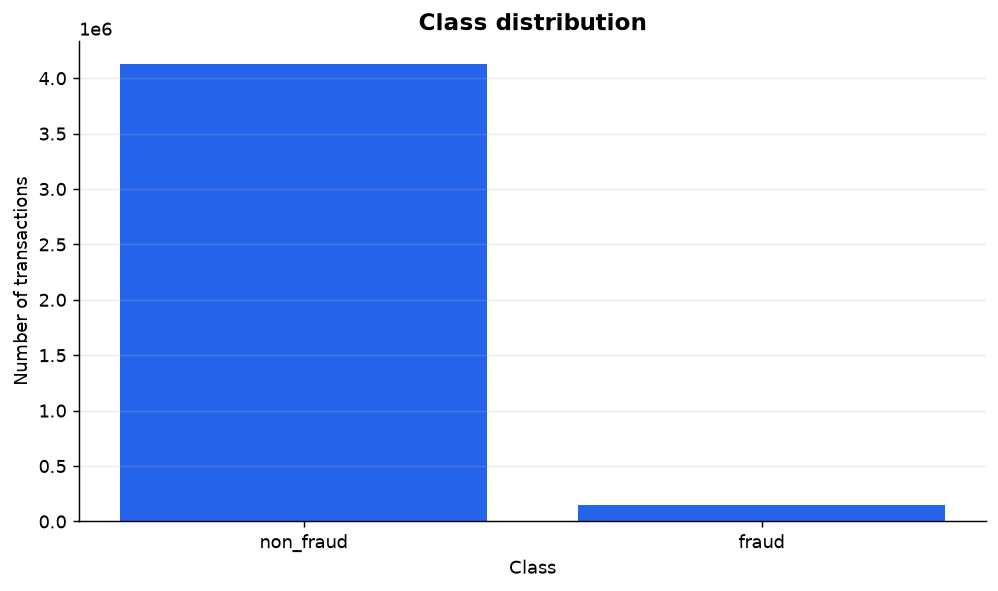

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(target_distribution["label"], target_distribution["row_count"], color=["#2563eb", "#dc2626"])
ax.set_title("Class distribution", fontsize=13, weight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of transactions")
ax.ticklabel_format(style="plain", axis="y")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.show()


### Chart Cell 2 - Fraud rate by transaction type

This chart compares fraud rates across transaction types. It helps check whether fraud is slightly more concentrated in a specific transaction context.


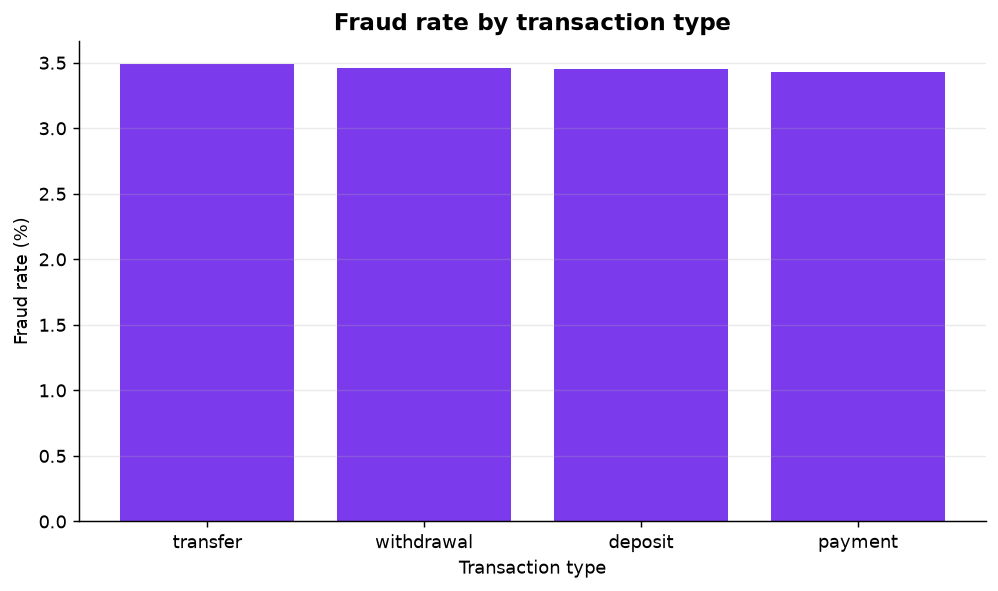

In [22]:
transaction_type_plot = categorical_summaries["transaction_type"].copy()
transaction_type_plot["fraud_rate_percent"] = transaction_type_plot["fraud_rate"] * 100
transaction_type_plot = transaction_type_plot.sort_values("fraud_rate_percent", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(transaction_type_plot["transaction_type"].astype(str), transaction_type_plot["fraud_rate_percent"], color="#7c3aed")
ax.set_title("Fraud rate by transaction type", fontsize=13, weight="bold")
ax.set_xlabel("Transaction type")
ax.set_ylabel("Fraud rate (%)")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.show()


### Chart Cell 3 - Fraud rate by hour

This chart shows whether fraud rates vary by hour of day. Time is a meaningful behavioral context in transaction data.


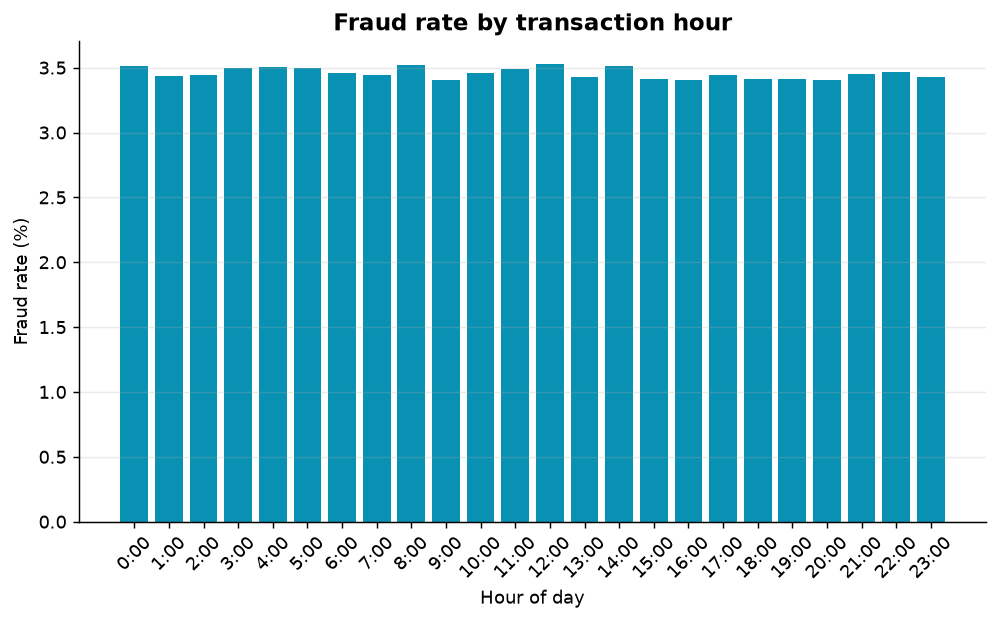

In [23]:
hourly_plot = hourly_summary.copy()
hourly_plot["hour_label"] = hourly_plot["transaction_hour"].astype(str) + ":00"
hourly_plot["fraud_rate_percent"] = hourly_plot["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(hourly_plot["hour_label"], hourly_plot["fraud_rate_percent"], color="#0891b2")
ax.set_title("Fraud rate by transaction hour", fontsize=13, weight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
ax.tick_params(axis="x", rotation=45)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.show()


### Chart Cell 4 - Fraud rate by amount band

This chart groups transaction amounts into interpretable bands. It is useful because transaction amount is skewed, and bands are easier to discuss than individual raw values.


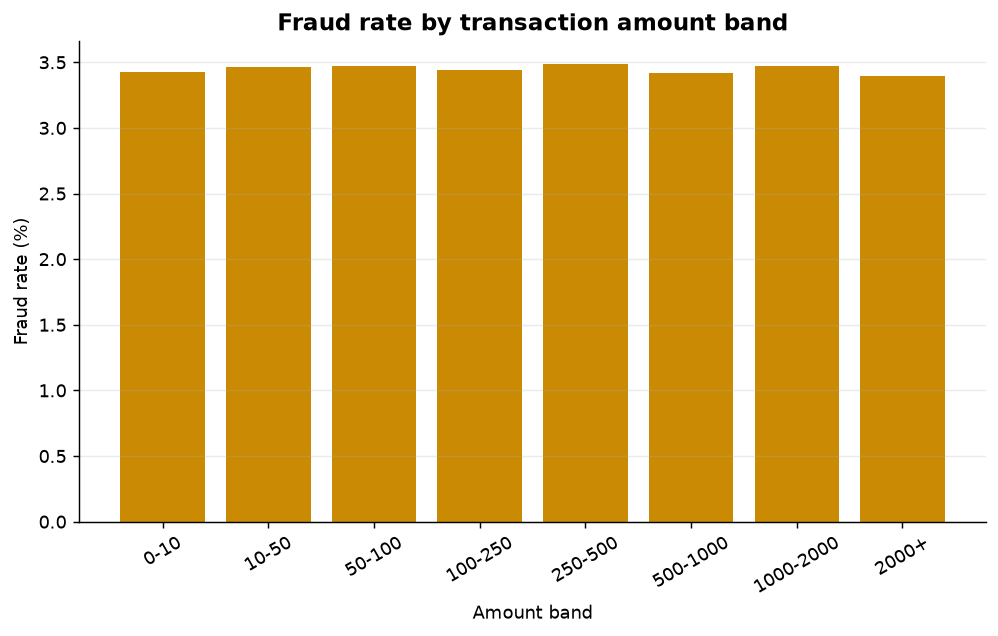

In [24]:
amount_bin_plot = amount_bin_summary.copy()
amount_bin_plot["fraud_rate_percent"] = amount_bin_plot["fraud_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(amount_bin_plot["amount_bin"].astype(str), amount_bin_plot["fraud_rate_percent"], color="#ca8a04")
ax.set_title("Fraud rate by transaction amount band", fontsize=13, weight="bold")
ax.set_xlabel("Amount band")
ax.set_ylabel("Fraud rate (%)")
ax.tick_params(axis="x", rotation=30)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.show()


### Chart Cell 5 - Numeric correlation with the fraud target

This chart shows simple Pearson correlations between numeric features and the fraud label. It is descriptive only and should not be treated as final feature selection.


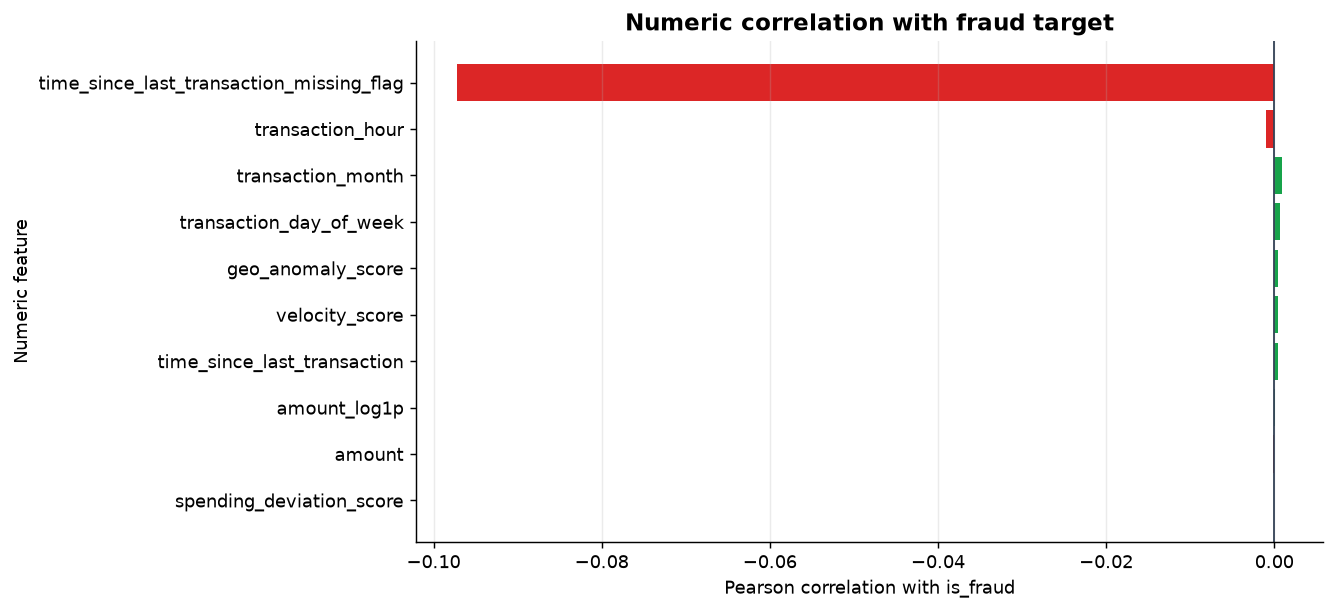

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#16a34a" if value >= 0 else "#dc2626" for value in target_correlation["pearson_correlation_with_is_fraud"]]
ax.barh(target_correlation["feature"], target_correlation["pearson_correlation_with_is_fraud"], color=colors)
ax.axvline(0, color="#334155", linewidth=1)
ax.set_title("Numeric correlation with fraud target", fontsize=13, weight="bold")
ax.set_xlabel("Pearson correlation with is_fraud")
ax.set_ylabel("Numeric feature")
ax.invert_yaxis()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.show()
